# Tirth Ajagiya || 23010101005

# Apriori Algorithm Implementation Assignment

### Objective:
You will implement the **Apriori algorithm** from scratch (i.e., without using any libraries like `mlxtend`) to find frequent itemsets and generate association rules.

### Dataset:
Use the [Online Retail Dataset](https://www.kaggle.com/datasets/vijayuv/onlineretail) from Kaggle. You can filter it for a specific country (e.g., `United Kingdom`) and time range to reduce size if needed.

---

## Step 1: Data Preprocessing

- Load the dataset
- Remove rows with missing values
- Filter out rows where `Quantity <= 0`
- Convert Data into Basket Format

👉 **Implement code below**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

df = df.dropna()

df = df[df['Quantity'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[(df['Country'] == 'United Kingdom') & (df['InvoiceDate'].dt.year == 2011)]

basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().reset_index().fillna(0).set_index('InvoiceNo')
basket = basket.map(lambda x: 1 if x > 0 else 0)  

transactions = [set(basket.columns[basket.iloc[i] == 1]) for i in range(basket.shape[0])]

print(f"Number of transactions: {len(transactions)}")
print("Sample transaction:", transactions if transactions else "No transactions")

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Step 2: Implement Apriori Algorithm
Step-by-Step Procedure:
1. Generate Frequent 1-Itemsets
Count the frequency (support) of each individual item in the dataset.
Keep only those with support ≥ min_support.
→ Result is L1 (frequent 1-itemsets)
2. Iterative Candidate Generation (k = 2 to n)
While L(k-1) is not empty:
a. Candidate Generation

Generate candidate itemsets Ck of size k from L(k-1) using the Apriori property:
Any (k-itemset) is only frequent if all of its (k−1)-subsets are frequent.
b. Prune Candidates
Eliminate candidates that have any (k−1)-subset not in L(k-1).
c. Count Support
For each transaction, count how many times each candidate in Ck appears.
d. Generate Frequent Itemsets
Form Lk by keeping candidates from Ck that meet the min_support.
Repeat until Lk becomes empty.
Implement the following functions:
1. `get_frequent_itemsets(transactions, min_support)` - Returns frequent itemsets and their support
2. `generate_candidates(prev_frequent_itemsets, k)` - Generates candidate itemsets of length `k`
3. `calculate_support(transactions, candidates)` - Calculates the support count for each candidate

**Write reusable functions** for each part of the algorithm.

In [8]:
from collections import defaultdict
from itertools import combinations

def get_frequent_itemsets(transactions, min_support):
    
    if not transactions:
        return {}
    
    total_transactions = len(transactions)
    min_count = int(total_transactions * min_support)  
    
    item_counts = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            item_counts[frozenset([item])] += 1
    
    frequent_itemsets = {itemset: count for itemset, count in item_counts.items() if count >= min_count}
    all_frequent_itemsets = dict(frequent_itemsets) 
    
    k = 2
    current_frequent = list(frequent_itemsets.keys())
    
    while current_frequent:
        candidates = generate_candidates(current_frequent, k)
        
        if not candidates:
            break
        
        candidate_counts = calculate_support(transactions, candidates)
        
        new_frequent = {itemset: count for itemset, count in candidate_counts.items() if count >= min_count}
        
        if not new_frequent:
            break
        
        all_frequent_itemsets.update(new_frequent)
        
        current_frequent = list(new_frequent.keys())
        k += 1
    
    frequent_itemsets_support = {itemset: count / total_transactions for itemset, count in all_frequent_itemsets.items()}
    
    return frequent_itemsets_support

def generate_candidates(prev_frequent_itemsets, k):
    
    candidates = set()
    for i in range(len(prev_frequent_itemsets)):
        for j in range(i + 1, len(prev_frequent_itemsets)):
            set1 = prev_frequent_itemsets[i]
            set2 = prev_frequent_itemsets[j]
            union_set = set1 | set2
            if len(union_set) == k:
                subsets = [frozenset(subset) for subset in combinations(union_set, k - 1)]
                if all(subset in prev_frequent_itemsets for subset in subsets):
                    candidates.add(frozenset(union_set))
    return list(candidates)

def calculate_support(transactions, candidates):
    
    counts = defaultdict(int)
    for transaction in transactions:
        transaction_set = frozenset(transaction)
        for candidate in candidates:
            if candidate.issubset(transaction_set):
                counts[candidate] += 1
    return counts


## Step 3: Generate Association Rules

- Use frequent itemsets to generate association rules
- For each rule `A => B`, calculate:
  - **Support**
  - **Confidence**
- Only return rules that meet a minimum confidence threshold (e.g., 0.5)

👉 **Implement rule generation function below**

In [9]:
def generate_rules(frequent_itemsets, min_confidence):
    
    rules = []
    for itemset, support in frequent_itemsets.items():
        if len(itemset) > 1:
            for antecedent_size in range(1, len(itemset)):
                for antecedent in combinations(itemset, antecedent_size):
                    antecedent = frozenset(antecedent)
                    consequent = itemset - antecedent
                    if antecedent in frequent_itemsets:
                        antecedent_support = frequent_itemsets[antecedent]
                        confidence = support / antecedent_support
                        if confidence >= min_confidence:
                            rules.append({
                                'antecedent': set(antecedent),  
                                'consequent': set(consequent),
                                'support': support,
                                'confidence': confidence
                            })
    rules.sort(key=lambda x: x['confidence'], reverse=True)
    return rules


## Step 4: Output and Visualize

- Print top 10 frequent itemsets
- Print top 10 association rules (by confidence or lift)

👉 **Output results below**

Top 10 Frequent Itemsets:
{'WHITE HANGING HEART T-LIGHT HOLDER'}: Support = 0.1099
{'JUMBO BAG RED RETROSPOT'}: Support = 0.0893
{'REGENCY CAKESTAND 3 TIER'}: Support = 0.0839
{'PARTY BUNTING'}: Support = 0.0828
{'ASSORTED COLOUR BIRD ORNAMENT'}: Support = 0.0790
{'LUNCH BAG RED RETROSPOT'}: Support = 0.0700
{'SET OF 3 CAKE TINS PANTRY DESIGN '}: Support = 0.0630
{'LUNCH BAG  BLACK SKULL.'}: Support = 0.0620
{'SPOTTY BUNTING'}: Support = 0.0591
{'NATURAL SLATE HEART CHALKBOARD '}: Support = 0.0573

Top 10 Association Rules (by Confidence):
{'JUMBO BAG PINK POLKADOT'} => {'JUMBO BAG RED RETROSPOT'}: Support = 0.0316, Confidence = 0.6218


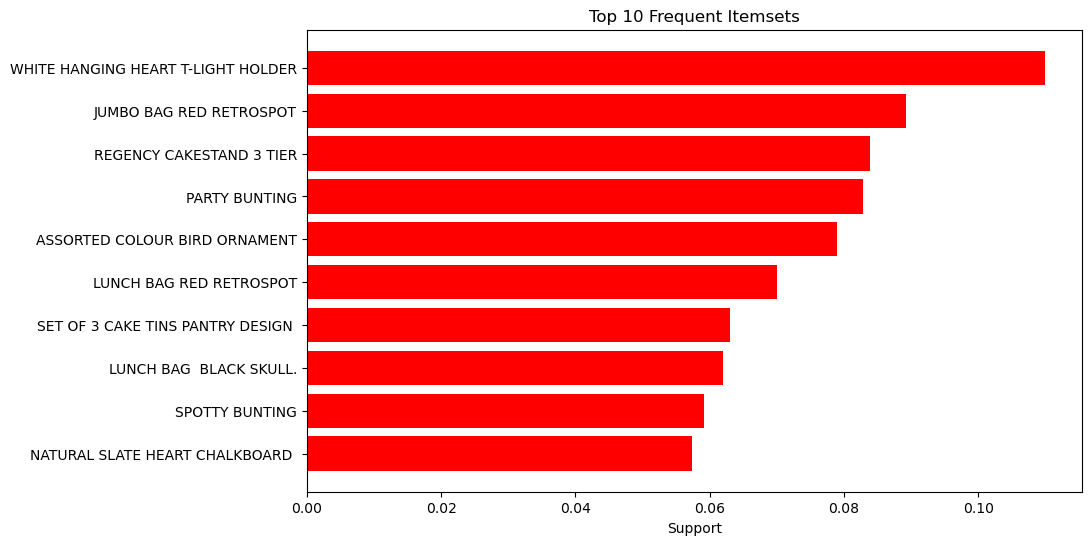

In [10]:
min_support = 0.03  
frequent_itemsets = get_frequent_itemsets(transactions, min_support)

min_confidence = 0.5 
rules = generate_rules(frequent_itemsets, min_confidence)

print("Top 10 Frequent Itemsets:")
sorted_itemsets = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:10]
for itemset, support in sorted_itemsets:
    print(f"{set(itemset)}: Support = {support:.4f}")

print("\nTop 10 Association Rules (by Confidence):")
for rule in rules[:10]:
    print(f"{rule['antecedent']} => {rule['consequent']}: Support = {rule['support']:.4f}, Confidence = {rule['confidence']:.4f}")

top_itemsets_labels = [', '.join(set(itemset)) for itemset, _ in sorted_itemsets]
top_supports = [support for _, support in sorted_itemsets]

plt.figure(figsize=(10, 6))
plt.barh(top_itemsets_labels, top_supports, color='red')
plt.xlabel('Support')
plt.title('Top 10 Frequent Itemsets')
plt.gca().invert_yaxis()  
plt.show()
